In [3]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'], errors='coerce')


Apply method

In [4]:
df[pd.notna(df['salary_year_avg'])]['salary_year_avg'].head(10)

28     109500.0
77     140000.0
92     120000.0
100    228222.0
109     89000.0
116    114000.0
146    129500.0
180     90250.0
212    157500.0
257    103128.0
Name: salary_year_avg, dtype: float64

In [5]:
# help(df.apply)

def project_salary (salary):
    return salary*1.03

df_salary = df[pd.notna(df['salary_year_avg'])].copy()
#df['salary_year_avg'].apply(project_salary)

#df_salary['salary_year_avg_deflated'] = df_salary['salary_year_avg']*1.03
#df_salary['salary_year_avg_deflated'] = df_salary['salary_year_avg'].apply(project_salary)
df_salary['salary_year_avg_deflated'] = df_salary['salary_year_avg'].apply(lambda _: _*1.03)


df_salary[['salary_year_avg', 'salary_year_avg_deflated']].head(5)


,salary_year_avg,salary_year_avg_deflated
28,109500.0,112785.00
77,140000.0,144200.00
92,120000.0,123600.00
100,228222.0,235068.66
109,89000.0,91670.00


In [6]:
import ast

skills = ast.literal_eval(df['job_skills'][3])
print(type(skills))
skills

<class 'list'>


['python', 'c++', 'java', 'matlab', 'aws', 'tensorflow', 'keras', 'pytorch']

In [7]:
import ast

def clean_list (skill_lsit):
    return ast.literal_eval(skill_lsit)


# if we do not handle nan values, as the clean_list expects a str, it thrws an error for nan values
skills = df.loc[df['job_skills'].notna(), 'job_skills'].head(3)

cleaned_data = [clean_list(x) for x in skills]
cleaned_data_1 = skills.apply(clean_list)
cleaned_data_2 = [ast.literal_eval(x) for x in skills]
cleaned_data_3 = skills.apply(lambda x: ast.literal_eval(x))

#The following command does not work as clean_list receives the generator instead of an individual skill string
# clean_list(x for x in df[pd.notna(df['job_skills'])]['job_skills'].head(3)) 
print(cleaned_data)
print("============================")
print(cleaned_data_1)
print("============================")
print(cleaned_data_2)
print("============================")
print(cleaned_data_3)


[['r', 'python', 'sql', 'nosql', 'power bi', 'tableau'], ['python', 'sql', 'c#', 'azure', 'airflow', 'dax', 'docker', 'kubernetes', 'jenkins'], ['python', 'c++', 'java', 'matlab', 'aws', 'tensorflow', 'keras', 'pytorch']]
1           [r, python, sql, nosql, power bi, tableau]
2    [python, sql, c#, azure, airflow, dax, docker,...
3    [python, c++, java, matlab, aws, tensorflow, k...
Name: job_skills, dtype: object
[['r', 'python', 'sql', 'nosql', 'power bi', 'tableau'], ['python', 'sql', 'c#', 'azure', 'airflow', 'dax', 'docker', 'kubernetes', 'jenkins'], ['python', 'c++', 'java', 'matlab', 'aws', 'tensorflow', 'keras', 'pytorch']]
1           [r, python, sql, nosql, power bi, tableau]
2    [python, sql, c#, azure, airflow, dax, docker,...
3    [python, c++, java, matlab, aws, tensorflow, k...
Name: job_skills, dtype: object


<Axes: xlabel='job_title_short'>

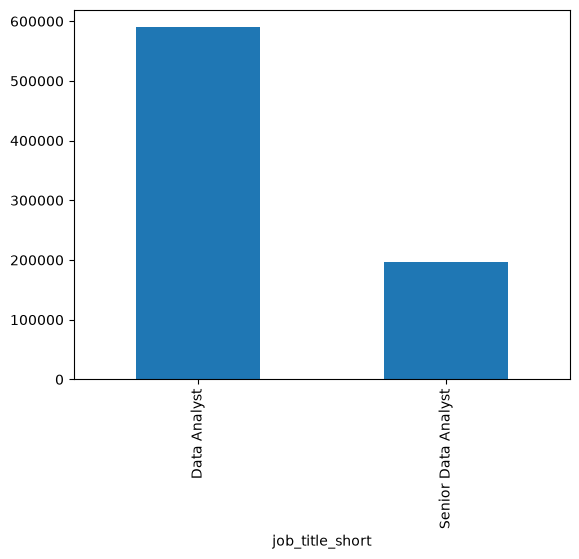

In [8]:
#help(df.isin)
df['job_title_short'].isin(['Data Analyst']).value_counts().plot(kind='bar')
df.loc[df['job_title_short'].str.contains('Data Analyst', na=False),'job_title_short'].value_counts().plot(kind='bar')

# this was we can apply functions to specific values, for example infllation only to job='Data Analyst' 
# through df.loc[df['job_title_short'].str.contains('Data Analyst', na=False),'salary_year_avg'].apply(lambda x:x *1.03)

In [9]:
#we can work directly with rows as well, as the apply() function has input (axis=0 or 1) to specify row or column applying to.

def projected_salary (row):
    if "Senior" in row['job_title_short']:
        return row['salary_year_avg']*1.05
    else: 
        return row['salary_year_avg']

# two different approaches to handle nan values:
df_salaries = df.loc[df['salary_year_avg'].notna()]
df_salary = df.loc[pd.notna(df['salary_year_avg'])].copy()

#apply adjustments on salary_yea_avg, normal and lambda approach
df_salary['salary_year_avg_deflated'] = df_salary.apply(projected_salary, axis=1)
df_salary['salary_year_avg_deflated_lambda'] = df_salary.apply(lambda x: x['salary_year_avg']*1.05 
                                                        if "Senior" in x['job_title_short'] 
                                                        else x['salary_year_avg'], axis=1)

#comparing results
df_salary[['job_title_short', 'salary_year_avg', 'salary_year_avg_deflated', 'salary_year_avg_deflated_lambda']].head(100)

,job_title_short,salary_year_avg,salary_year_avg_deflated,salary_year_avg_deflated_lambda
28,Data Scientist,109500.0,109500.0,109500.0
77,Data Engineer,140000.0,140000.0,140000.0
92,Data Engineer,120000.0,120000.0,120000.0
100,Data Scientist,228222.0,228222.0,228222.0
109,Data Analyst,89000.0,89000.0,89000.0
...,...,...,...,...
2765,Data Engineer,150000.0,150000.0,150000.0
2766,Senior Data Engineer,173500.0,182175.0,182175.0
2785,Data Engineer,147500.0,147500.0,147500.0
2816,Senior Data Scientist,170000.0,178500.0,178500.0


In pandas, .explode() takes values that contain lists and expands each item in the list into its own row.
It helps in the following way:

In [10]:
df_small = pd.DataFrame({
    'job_title': ['Data Analyst', 'Data Scientist'],
    'job_skills': [
        ['python', 'sql', 'excel'],
        ['python', 'tensorflow']
    ]
})

df_small

,job_title,job_skills
0,Data Analyst,"[python, sql, excel]"
1,Data Scientist,"[python, tensorflow]"


In [11]:
df_small.explode('job_skills')

,job_title,job_skills
0,Data Analyst,python
0,Data Analyst,sql
0,Data Analyst,excel
1,Data Scientist,python
1,Data Scientist,tensorflow


<Axes: xlabel='job_skills'>

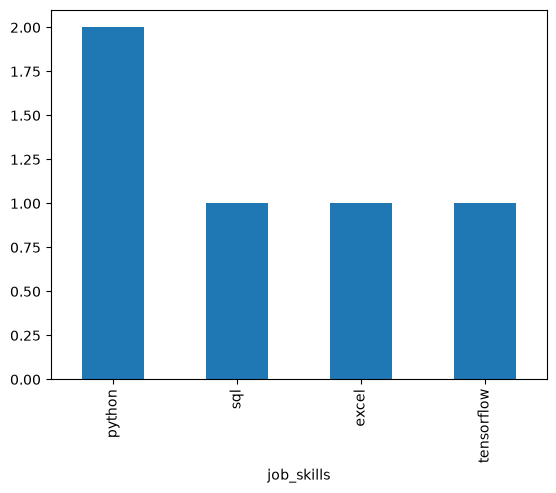

In [12]:
df_exploded = df_small.explode('job_skills')
df_exploded['job_skills'].value_counts().plot(kind='bar')

<Axes: xlabel='job_skills'>

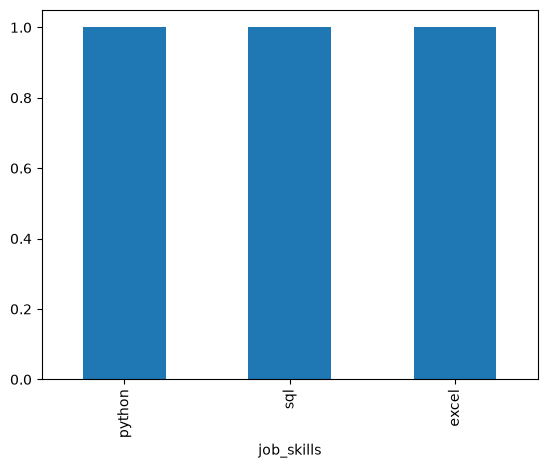

In [14]:
df_exploded = df_small.explode('job_skills')
df_exploded[
    df_exploded['job_title'] == 'Data Analyst'
]['job_skills'].value_counts().plot(kind='bar')